# PART B- DATA ACQUISITION

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import requests
import sqlite3

In [3]:
df = pd.read_csv('customer_churn_dataset-testing-master.csv')

In [4]:
df_json= pd.read_json('customer_churn_sample.json')
df_json.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
conn = sqlite3.connect('customer_churn_sample.db')
table = pd.read_sql_query("SELECT * FROM customer_churn", conn)
table.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [6]:
url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)
data = response.json()[:10]
df_api = pd.DataFrame(data)
df_api.head()

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


# Part C - data cleaning

In [7]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [8]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [10]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [11]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop(
    columns=["CustomerID"]
)

df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [14]:
df.dtypes

Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

In [15]:
df.shape

(64374, 11)

# PART D- EDA(EXPLORATORY DATA ANALYSIS)

## UNIVARIATE ANALYSIS

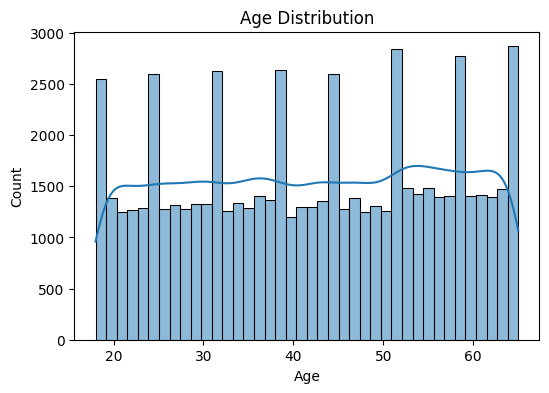

In [16]:
plt.figure(figsize=(6,4))

sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution")

plt.show()

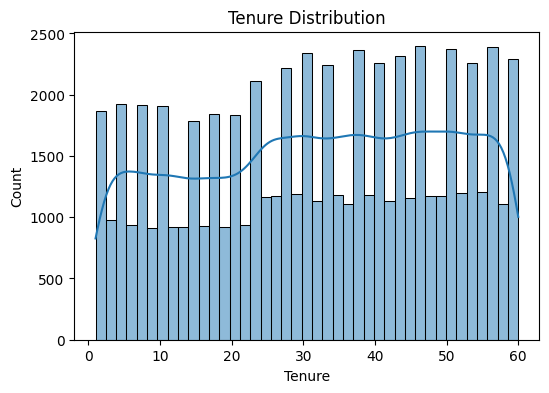

In [17]:
plt.figure(figsize=(6,4))

sns.histplot(df["Tenure"], kde=True)

plt.title("Tenure Distribution")

plt.show()

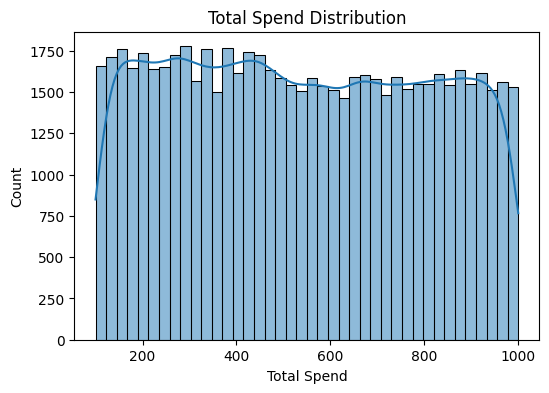

In [18]:
plt.figure(figsize=(6,4))

sns.histplot(df["Total Spend"], kde=True)

plt.title("Total Spend Distribution")

plt.show()

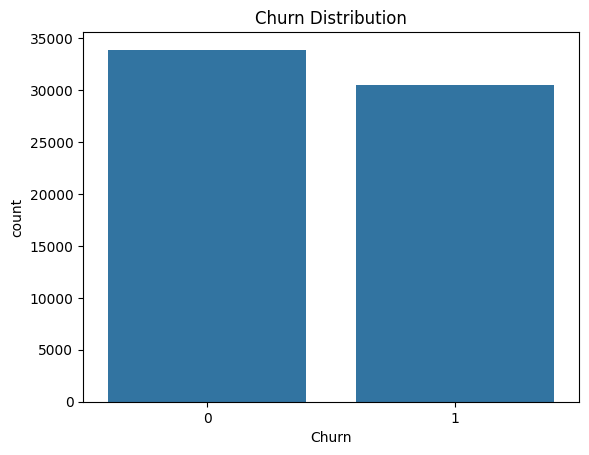

In [19]:
sns.countplot(
    x="Churn",
    data=df
)

plt.title("Churn Distribution")

plt.show()

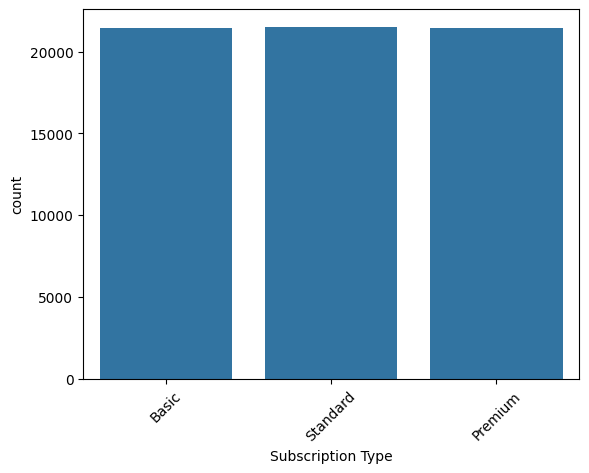

In [20]:
sns.countplot(
    x="Subscription Type",
    data=df
)

plt.xticks(rotation=45)

plt.show()

## Bivariate Analysis

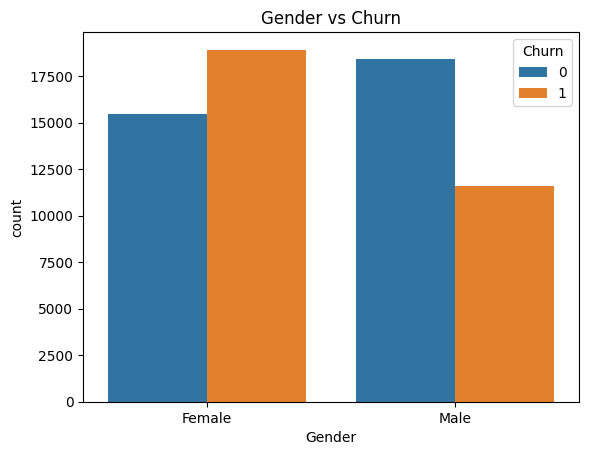

In [21]:
#Gender vs Churn

sns.countplot(
    x="Gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")

plt.show()

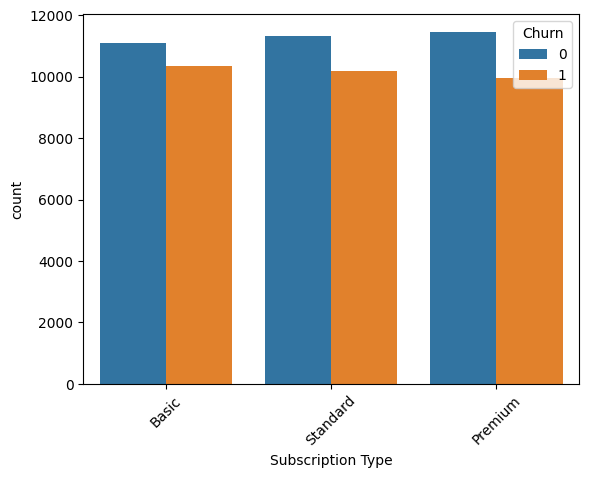

In [22]:
# Subscription Type vs Churn

sns.countplot(
    x="Subscription Type",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.show()

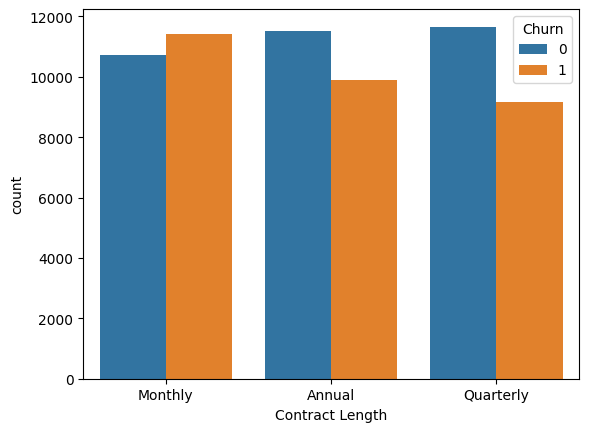

In [23]:
# Contract Length vs Churn

sns.countplot(
    x="Contract Length",
    hue="Churn",
    data=df
)

plt.show()

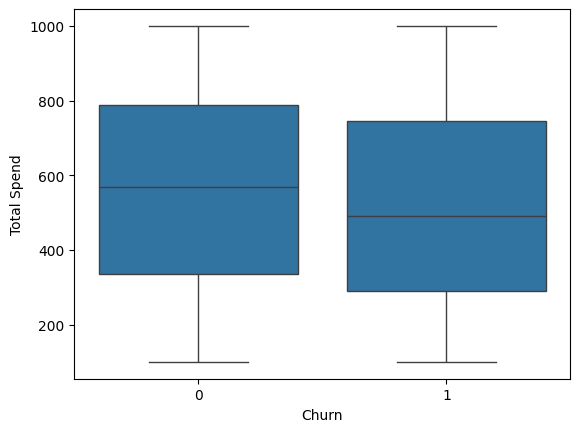

In [24]:
# Total Spend vs Churn

sns.boxplot(
    x="Churn",
    y="Total Spend",
    data=df
)

plt.show()

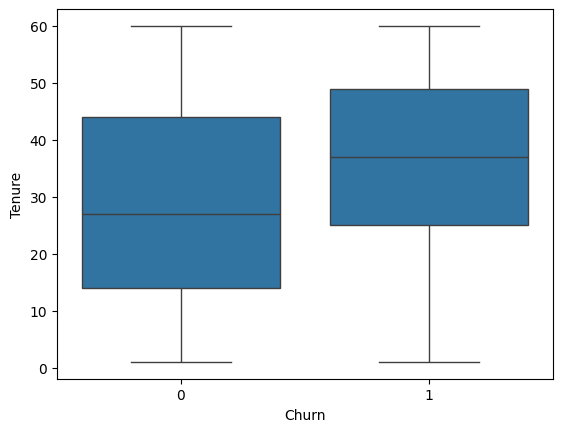

In [25]:
# Tenure vs Churn

sns.boxplot(
    x="Churn",
    y="Tenure",
    data=df
)

plt.show()

## MULTIVARIAT ANALYSIS

In [26]:
num_df = df.select_dtypes(include="number")

num_df.corr()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457
Tenure,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327
Usage Frequency,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098
Support Calls,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631
Payment Delay,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386
Total Spend,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867
Last Interaction,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818
Churn,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000


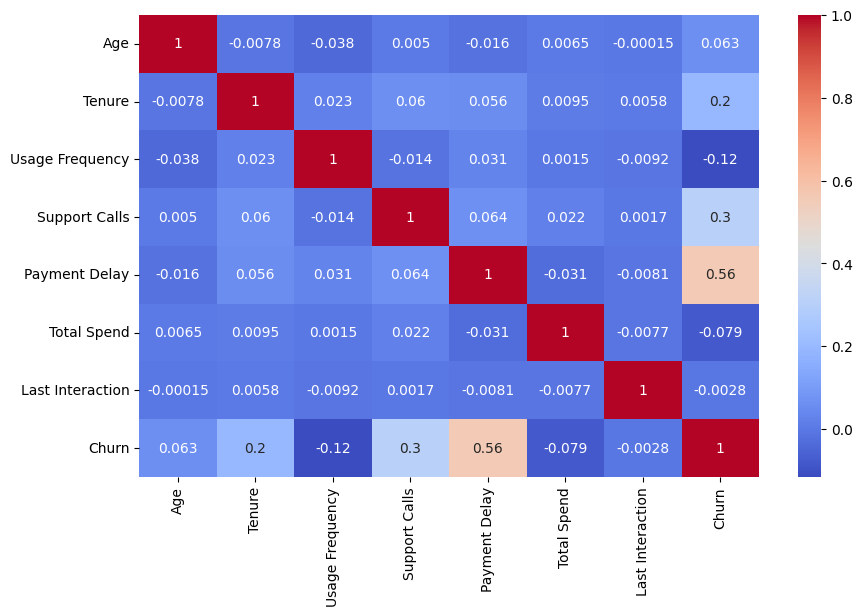

In [27]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

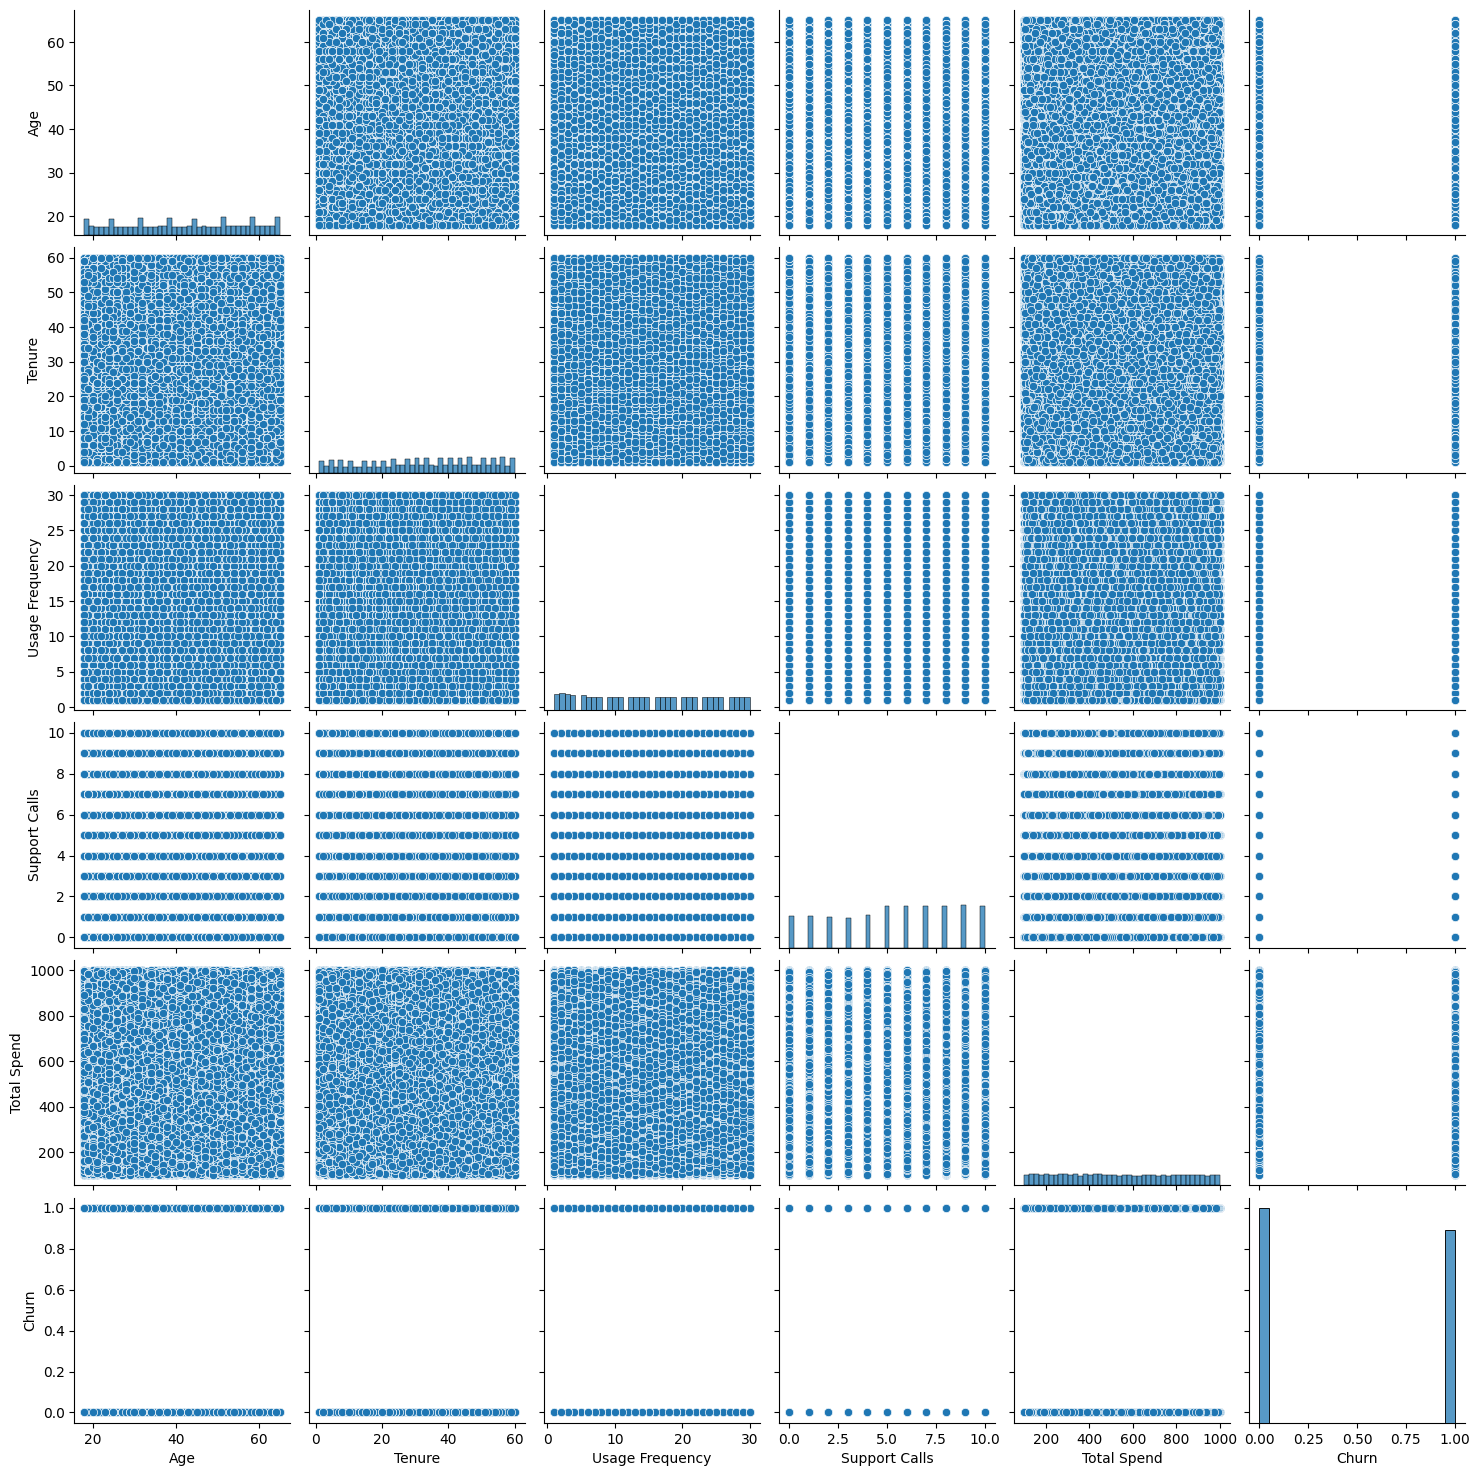

In [28]:
# Pairplot

sns.pairplot(
    df[
        [
            "Age",
            "Tenure",
            "Usage Frequency",
            "Support Calls",
            "Total Spend",
            "Churn"
        ]
    ]
)

plt.show()

# PART E : data profiling

In [29]:
#Create Spend Per Month Feature

df["Spend_Per_Tenure"] = (
    df["Total Spend"] /
    (df["Tenure"] + 1)
)

df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Spend_Per_Tenure
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1,23.000000
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0,20.137931
2,47,Male,27,10,2,29,Premium,Annual,757,21,0,27.035714
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0,23.200000
4,53,Female,58,24,9,2,Standard,Annual,533,18,0,9.033898


In [30]:
df[["Total Spend","Tenure","Spend_Per_Tenure"]].head()

,Total Spend,Tenure,Spend_Per_Tenure
0,598,25,23.000000
1,584,28,20.137931
2,757,27,27.035714
3,232,9,23.200000
4,533,58,9.033898


In [31]:
# Missing Values

df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
Spend_Per_Tenure     0
dtype: int64

In [32]:
# Descriptive Statistics

df.describe(include="all")

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Spend_Per_Tenure
count,64374.000000,64374,64374.000000,64374.000000,64374.000000,64374.000000,64374,64374,64374.000000,64374.000000,64374.000000,64374.000000
unique,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN,NaN,Standard,Monthly,NaN,NaN,NaN,NaN
freq,NaN,34353,NaN,NaN,NaN,NaN,21502,22130,NaN,NaN,NaN,NaN
mean,41.970982,NaN,31.994827,15.080234,5.400690,17.133952,NaN,NaN,541.023379,15.498850,0.473685,30.813612
std,13.924911,NaN,17.098234,8.816470,3.114005,8.852211,NaN,NaN,260.874809,8.638436,0.499311,48.748167
min,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000,1.655738
25%,30.000000,NaN,18.000000,7.000000,3.000000,10.000000,NaN,NaN,313.000000,8.000000,0.000000,9.500000
50%,42.000000,NaN,33.000000,15.000000,6.000000,19.000000,NaN,NaN,534.000000,15.000000,0.000000,16.333333
75%,54.000000,NaN,47.000000,23.000000,8.000000,25.000000,NaN,NaN,768.000000,23.000000,1.000000,29.275862


In [33]:
# Correlations

num_df = df.select_dtypes(include="number")
num_df.corr()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Spend_Per_Tenure
Age,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457,0.008286
Tenure,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327,-0.570689
Usage Frequency,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098,-0.025326
Support Calls,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631,-0.032662
Payment Delay,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386,-0.039986
Total Spend,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867,0.301746
Last Interaction,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818,-0.004485
Churn,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000,-0.139887
Spend_Per_Tenure,0.008286,-0.570689,-0.025326,-0.032662,-0.039986,0.301746,-0.004485,-0.139887,1.000000


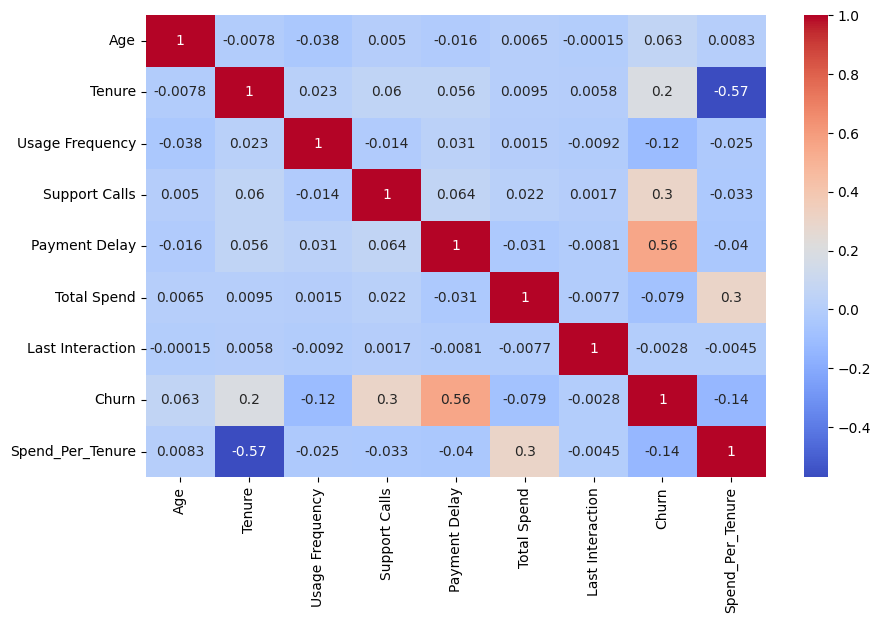

In [35]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [36]:
# Data Quality Check

print("Duplicate Rows:", df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)

Duplicate Rows: 0

Data Types:
Age                    int64
Gender                object
Tenure                 int64
Usage Frequency        int64
Support Calls          int64
Payment Delay          int64
Subscription Type     object
Contract Length       object
Total Spend            int64
Last Interaction       int64
Churn                  int64
Spend_Per_Tenure     float64
dtype: object
